In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm

In [2]:
df = pd.read_csv('loan.csv')

In [94]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_log,TotalIncome,TotalIncome_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360,1.0,Urban,Y,146.412162,5849.0,8.674026
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360,1.0,Rural,N,128.000000,6091.0,8.714568
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360,1.0,Urban,Y,66.000000,3000.0,8.006368
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360,1.0,Urban,Y,120.000000,4941.0,8.505323
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360,1.0,Urban,Y,141.000000,6000.0,8.699515


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

(array([ 2.,  7., 14., 17., 32., 32., 68., 74., 88., 48., 52., 22., 44.,
        14., 11.,  6.,  6.,  7.,  9.,  5.,  4.,  5.,  3.,  1.,  2.,  1.,
         3.,  0.,  2.,  0.,  1.,  0.,  0.,  0.,  4.,  3.,  0.,  0.,  0.,
         0.,  1.,  0.,  2.,  0.,  0.,  0.,  1.,  0.,  0.,  1.]),
 array([  9.  ,  22.82,  36.64,  50.46,  64.28,  78.1 ,  91.92, 105.74,
        119.56, 133.38, 147.2 , 161.02, 174.84, 188.66, 202.48, 216.3 ,
        230.12, 243.94, 257.76, 271.58, 285.4 , 299.22, 313.04, 326.86,
        340.68, 354.5 , 368.32, 382.14, 395.96, 409.78, 423.6 , 437.42,
        451.24, 465.06, 478.88, 492.7 , 506.52, 520.34, 534.16, 547.98,
        561.8 , 575.62, 589.44, 603.26, 617.08, 630.9 , 644.72, 658.54,
        672.36, 686.18, 700.  ]),
 <BarContainer object of 50 artists>)

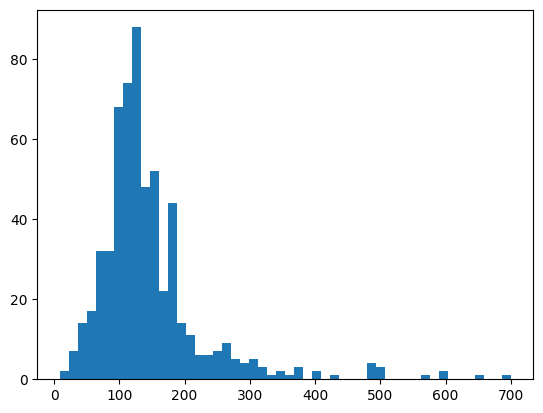

In [10]:
plt.hist(df['LoanAmount'] ,bins=50)

In [18]:
# to normalize the column distribution
df['LoanAmount_log'] = np.log(df['LoanAmount'])

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  2.,  1.,
         2.,  0.,  2.,  0.,  3.,  6.,  5.,  8.,  7.,  7., 17., 10., 19.,
        20., 50., 53., 58., 62., 48., 38., 36., 44., 16., 13., 10., 14.,
         8.,  7.,  3.,  6.,  2.,  1.,  4.,  3.,  1.,  2.,  2.]),
 array([2.19722458, 2.28430169, 2.37137881, 2.45845592, 2.54553304,
        2.63261015, 2.71968727, 2.80676438, 2.8938415 , 2.98091861,
        3.06799573, 3.15507284, 3.24214996, 3.32922707, 3.41630419,
        3.5033813 , 3.59045842, 3.67753553, 3.76461265, 3.85168977,
        3.93876688, 4.025844  , 4.11292111, 4.19999823, 4.28707534,
        4.37415246, 4.46122957, 4.54830669, 4.6353838 , 4.72246092,
        4.80953803, 4.89661515, 4.98369226, 5.07076938, 5.15784649,
        5.24492361, 5.33200072, 5.41907784, 5.50615495, 5.59323207,
        5.68030918, 5.7673863 , 5.85446341, 5.94154053, 6.02861764,
        6.11569476, 6.20277187, 6.28984899, 6.3769261 , 6.46400322,
        6.55108034]),
 <BarContainer

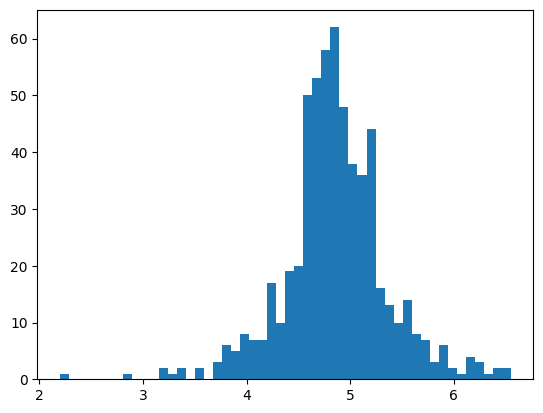

In [19]:
plt.hist(df['LoanAmount_log'] ,bins=50)

<Axes: >

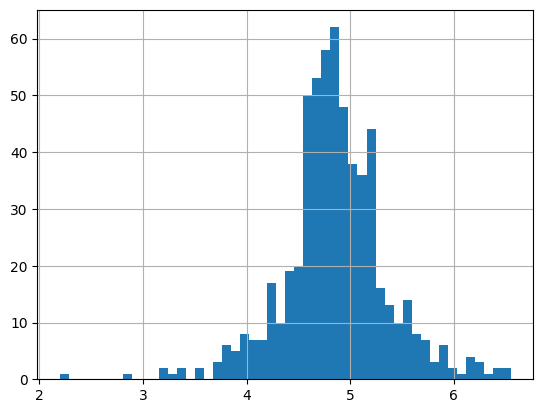

In [20]:
df['LoanAmount_log'].hist(bins=50)

In [95]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
LoanAmount_log       0
TotalIncome          0
TotalIncome_log      0
dtype: int64

In [22]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

<Axes: >

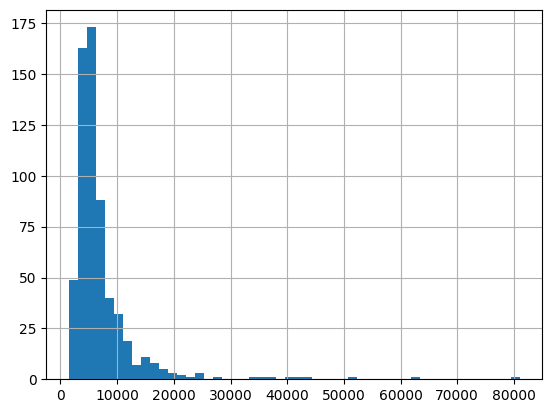

In [24]:
df['TotalIncome'].hist(bins=50)


<Axes: >

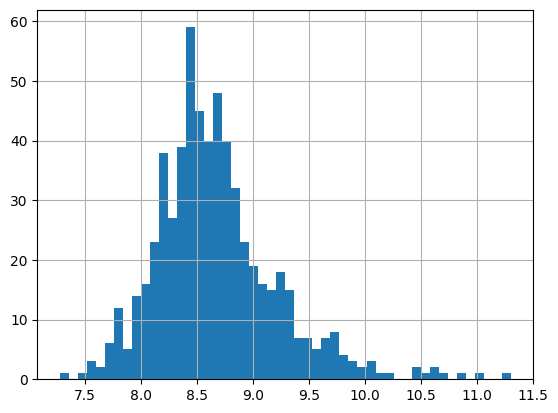

In [28]:
df['TotalIncome_log'] = np.log(df['TotalIncome'])
df['TotalIncome_log'].hist(bins=50)


In [30]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,loanAmount_log,LoanAmount_log,TotalIncome,TotalIncome_log
count,614.000000,614.000000,592.000000,600.00000,564.000000,592.000000,592.000000,614.000000,614.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199,4.857444,4.857444,7024.705081,8.669414
std,6109.041673,2926.248369,85.587325,65.12041,0.364878,0.505142,0.505142,6458.663872,0.545102
min,150.000000,0.000000,9.000000,12.00000,0.000000,2.197225,2.197225,1442.000000,7.273786
25%,2877.500000,0.000000,100.000000,360.00000,1.000000,4.605170,4.605170,4166.000000,8.334712
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000,4.852030,4.852030,5416.500000,8.597205
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000,5.123964,5.123964,7521.750000,8.925549
max,81000.000000,41667.000000,700.000000,480.00000,1.000000,6.551080,6.551080,81000.000000,11.302204


In [29]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
loanAmount_log       22
LoanAmount_log       22
TotalIncome           0
TotalIncome_log       0
dtype: int64

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    int64  
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
 13  LoanAmount_log     614 non-null    float64
 14  TotalIncome        614 non-null    float64
 15  TotalIncome_log    614 non-null    float64
dtypes: float64(6), int64(2), o

In [42]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace = True )
df['Married'].fillna(df['Married'].mode()[0], inplace = True )
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace = True )
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace = True )

df.LoanAmount = df.LoanAmount.fillna(df.LoanAmount.mean())
df.LoanAmount_log = df.LoanAmount.fillna(df.LoanAmount.mean())

mode_value = df['Loan_Amount_Term'].mode()
if not mode_value.empty:
    df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(mode_value[0])
else:
    # Handle the case where mode is empty, e.g., fill with a default value or leave as is
    df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(360)

#df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0] )
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

C:\Users\star-pc\AppData\Local\Temp\ipykernel_7908\149149819.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace = True )
C:\Users\star-pc\AppData\Local\Temp\ipykernel_7908\149149819.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [49]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
LoanAmount_log       0
TotalIncome          0
TotalIncome_log      0
dtype: int64

<Axes: >

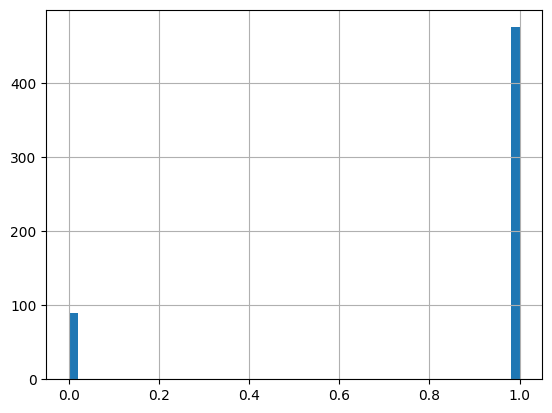

In [37]:
df['Credit_History'].hist(bins = 50)

In [47]:
df.drop('loanAmount_log', axis=1 ,inplace= True )

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    int64  
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
 13  LoanAmount_log     614 non-null    float64
 14  TotalIncome        614 non-null    float64
 15  TotalIncome_log    614 non-null    float64
dtypes: float64(6), int64(2), o

# Spliting the training and testing data

In [53]:
x= df.iloc[:,np.r_[1:5,9:11 ,13:15]].values
y= df.iloc[:,12].values

In [54]:
x

array([['Male', 'No', '0', ..., 1.0, 146.41216216216216, 5849.0],
       ['Male', 'Yes', '1', ..., 1.0, 128.0, 6091.0],
       ['Male', 'Yes', '0', ..., 1.0, 66.0, 3000.0],
       ...,
       ['Male', 'Yes', '1', ..., 1.0, 253.0, 8312.0],
       ['Male', 'Yes', '2', ..., 1.0, 187.0, 7583.0],
       ['Female', 'No', '0', ..., 0.0, 133.0, 4583.0]], dtype=object)

In [55]:
y

array(['Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'N', 'N', 'N', 'Y',
       'Y', 'Y', 'N', 'Y', 'N', 'N', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N',
       'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'N',
       'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'N',
       'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'N

In [56]:
print('per of mising gender is %2f%%' %((df['Gender'].isnull().sum()/df.shape[0])*100))

per of mising gender is 0.000000%


No.of people who took loan as group by gender :
Gender
Male      502
Female    112
Name: count, dtype: int64


<Axes: xlabel='Gender', ylabel='count'>

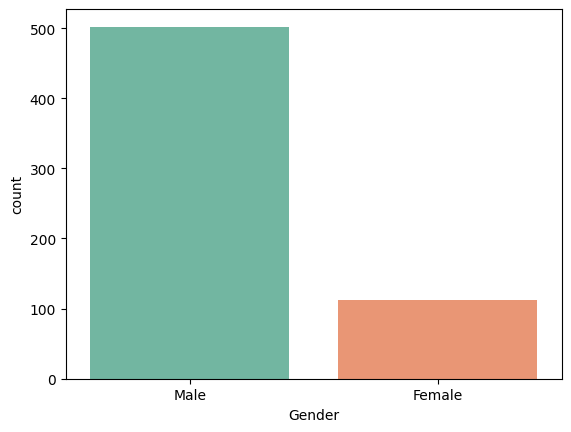

In [60]:
print("No.of people who took loan as group by gender :")
print(df['Gender'].value_counts())
sns.countplot(x='Gender', data=df, hue='Gender', palette='Set2', legend=False)


No.of people who took loan as group by "Marital status"  and then by "Gender" :
Married
Yes    401
No     213
Name: count, dtype: int64


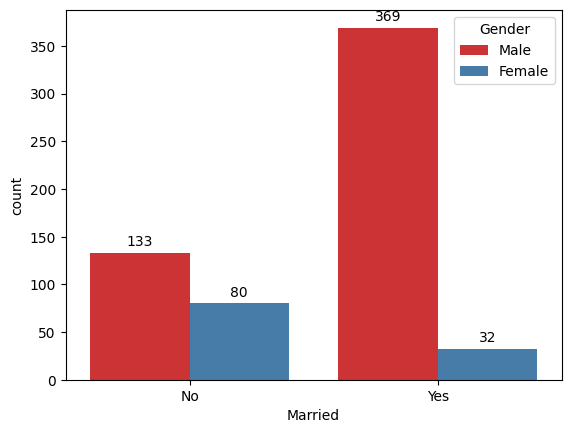

In [71]:
print("No.of people who took loan as group by \"Marital status\"  and then by \"Gender\" :")
print(df['Married'].value_counts())
ax=sns.countplot(x='Married', data=df, hue='Gender', palette='Set1', legend=True)
# Add count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

# Display the plot
plt.show()


No.of people who took loan as group by Dependents :
Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64


C:\Users\star-pc\AppData\Local\Temp\ipykernel_7908\382960532.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dependents', data=df, palette='Set3', legend=False)


<Axes: xlabel='Dependents', ylabel='count'>

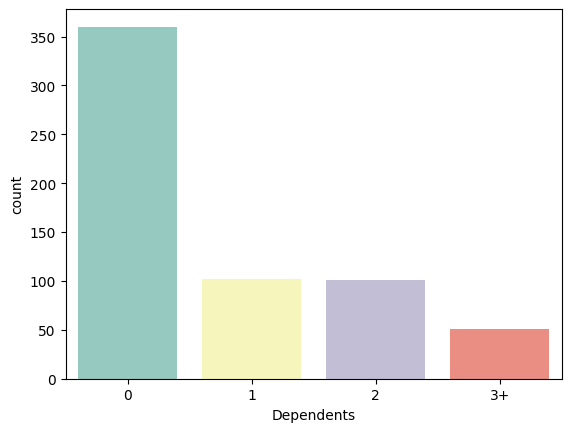

In [76]:
print("No.of people who took loan as group by Dependents :")
print(df['Dependents'].value_counts())
sns.countplot(x='Dependents', data=df, palette='Set3', legend=False)


No.of people who took loan as group by Self_Employed :
Self_Employed
No     532
Yes     82
Name: count, dtype: int64


C:\Users\star-pc\AppData\Local\Temp\ipykernel_7908\3481753728.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Self_Employed', data=df, palette='Set3', legend=False)


<Axes: xlabel='Self_Employed', ylabel='count'>

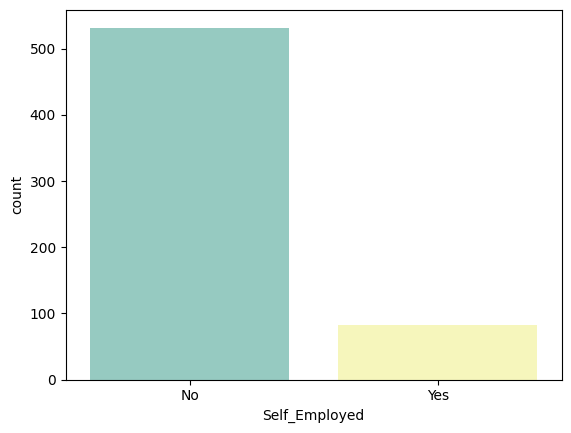

In [77]:
print("No.of people who took loan as group by Self_Employed :")
print(df['Self_Employed'].value_counts())
sns.countplot(x='Self_Employed', data=df, palette='Set3', legend=False)


No.of people who took loan as group by LoanAmount :
LoanAmount
146.412162    22
120.000000    20
110.000000    17
100.000000    15
187.000000    12
              ..
292.000000     1
142.000000     1
350.000000     1
496.000000     1
253.000000     1
Name: count, Length: 204, dtype: int64


C:\Users\star-pc\AppData\Local\Temp\ipykernel_7908\1756080935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LoanAmount', data=df, palette='Set3', legend=False)


<Axes: xlabel='LoanAmount', ylabel='count'>

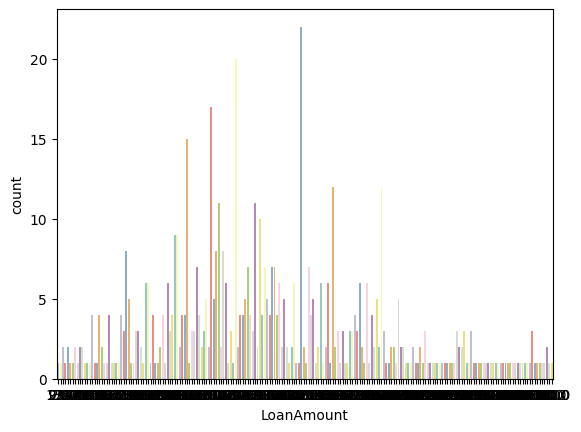

In [78]:
print("No.of people who took loan as group by LoanAmount :")
print(df['LoanAmount'].value_counts())
sns.countplot(x='LoanAmount', data=df, palette='Set3', legend=False)


No.of people who took loan as group by Credit_History :
Credit_History
1.0    525
0.0     89
Name: count, dtype: int64


C:\Users\star-pc\AppData\Local\Temp\ipykernel_7908\3760592648.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Credit_History', data=df, palette='Set3', legend=False)


<Axes: xlabel='Credit_History', ylabel='count'>

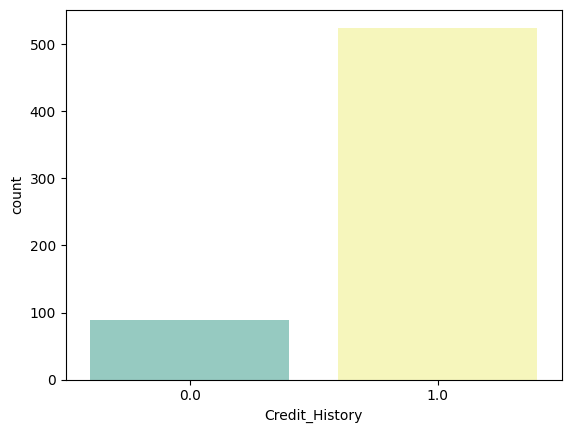

In [79]:
print("No.of people who took loan as group by Credit_History :")
print(df['Credit_History'].value_counts())
sns.countplot(x='Credit_History', data=df, palette='Set3', legend=False)


In [81]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x , y ,test_size= 0.2 ,random_state=0)

from sklearn.preprocessing import LabelEncoder
label_encoder_x = LabelEncoder()

In [93]:
print(x_train)

[['Male' 'Yes' '0' ... 1.0 131.0 5858.0]
 ['Male' 'No' '1' ... 1.0 196.0 11250.0]
 ['Male' 'Yes' '0' ... 0.0 149.0 5681.0]
 ...
 ['Male' 'Yes' '3+' ... 1.0 200.0 8334.0]
 ['Male' 'Yes' '0' ... 1.0 160.0 6033.0]
 ['Female' 'Yes' '0' ... 1.0 182.0 6486.0]]


# Encoding train data (x)

In [102]:
for i in range(0,5):
    x_train[:,i]  = label_encoder_x.fit_transform(x_train[:,i])
    x_train[:,7]  = label_encoder_x.fit_transform(x_train[:,7])

x_train

array([[1, 1, 0, ..., 1.0, 131.0, 267],
       [1, 0, 1, ..., 1.0, 196.0, 407],
       [1, 1, 0, ..., 0.0, 149.0, 249],
       ...,
       [1, 1, 3, ..., 1.0, 200.0, 363],
       [1, 1, 0, ..., 1.0, 160.0, 273],
       [0, 1, 0, ..., 1.0, 182.0, 301]], dtype=object)

In [103]:
label_encoder_y = LabelEncoder()
y_train = label_encoder_y.fit_transform(y_train)
y_train

array([1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,

# Encoding test data (y)

In [109]:
for i in range(0,5):
    x_test[:,i]  = label_encoder_x.fit_transform(x_test[:,i])
    x_test[:,7]  = label_encoder_x.fit_transform(x_test[:,7])

x_test

array([[1, 0, 0, 0, 0, 1.0, 84.0, 85],
       [0, 0, 0, 0, 0, 1.0, 112.0, 28],
       [1, 1, 0, 0, 0, 1.0, 324.0, 104],
       [1, 1, 0, 0, 0, 1.0, 110.0, 80],
       [1, 1, 2, 0, 0, 1.0, 97.0, 22],
       [1, 1, 0, 1, 0, 0.0, 165.0, 70],
       [1, 1, 3, 0, 0, 1.0, 157.0, 77],
       [1, 0, 0, 0, 0, 1.0, 405.0, 114],
       [1, 0, 0, 0, 0, 0.0, 124.0, 53],
       [1, 1, 0, 0, 0, 1.0, 128.0, 55],
       [0, 0, 0, 0, 0, 1.0, 84.0, 4],
       [1, 1, 1, 0, 0, 1.0, 95.0, 2],
       [0, 0, 0, 0, 0, 1.0, 280.0, 96],
       [1, 1, 2, 0, 0, 1.0, 236.0, 97],
       [1, 1, 0, 0, 0, 1.0, 96.0, 117],
       [1, 1, 1, 0, 0, 1.0, 67.0, 22],
       [1, 0, 1, 1, 0, 1.0, 190.0, 32],
       [1, 0, 0, 1, 0, 1.0, 132.0, 25],
       [0, 0, 0, 0, 0, 1.0, 93.0, 1],
       [1, 1, 0, 1, 0, 0.0, 181.0, 44],
       [0, 1, 0, 0, 0, 0.0, 120.0, 71],
       [1, 1, 0, 0, 0, 1.0, 143.0, 43],
       [1, 1, 2, 0, 0, 1.0, 108.0, 91],
       [1, 1, 2, 0, 0, 1.0, 165.0, 111],
       [1, 1, 0, 0, 0, 1.0, 58.0, 35],
       

In [105]:
label_encoder_y = LabelEncoder()
y_test = label_encoder_y.fit_transform(y_test)
y_test

array([1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1])

 # standardization using sklearn.standardScalar()

In [110]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
x_train = ss.fit_transform(x_train)
x_test = ss.fit_transform(x_test)

In [111]:
x_train

array([[ 0.47374983,  0.71143163, -0.76304669, ...,  0.41790088,
        -0.18814516,  0.29186348],
       [ 0.47374983, -1.40561644,  0.22549137, ...,  0.41790088,
         0.56269516,  1.36113256],
       [ 0.47374983,  0.71143163, -0.76304669, ..., -2.39291191,
         0.01977985,  0.15438603],
       ...,
       [ 0.47374983,  0.71143163,  2.2025675 , ...,  0.41790088,
         0.60890072,  1.02507656],
       [ 0.47374983,  0.71143163, -0.76304669, ...,  0.41790088,
         0.14684514,  0.3376893 ],
       [-2.11081869,  0.71143163, -0.76304669, ...,  0.41790088,
         0.40097571,  0.55154312]])

In [112]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier()
rf_clf.fit( x_train ,y_train )

RandomForestClassifier()

In [113]:
from sklearn import metrics
y_pred = rf_clf.predict(x_test)

print("accuracy of random forest classifer is : ", metrics.accuracy_score(y_pred,y_test))

y_pred

accuracy of random forest classifer is :  0.7723577235772358


array([1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1])

# Best model for Loan Approval Prediction : "Naive Bayes"
## with 83 % accuracy

In [127]:
from sklearn.naive_bayes import GaussianNB
nb_clf = GaussianNB()
nb_clf.fit(x_train, y_train)

GaussianNB()

In [128]:
y_pred = nb_clf.predict(x_test)
print("accuracy of  classifer is naive classifier : ", metrics.accuracy_score(y_pred,y_test))

y_pred

accuracy of  classifer is naive classifier :  0.8292682926829268


array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1])

In [118]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier()
dt_clf.fit(x_train,y_train)

DecisionTreeClassifier()

In [121]:
y_pred = dt_clf.predict(x_test)
print("accuracy of classifer is Decision tree classifier : ", metrics.accuracy_score(y_pred,y_test))

y_pred

accuracy of classifer is Decision tree classifier :  0.7235772357723578


array([0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1])

In [123]:
from sklearn.neighbors import KNeighborsClassifier
kn_clf = KNeighborsClassifier()
kn_clf.fit(x_train , y_train)

KNeighborsClassifier()

In [125]:
y_pred = kn_clf.predict(x_test)
print("accuracy of KNeighbors classifier : ", metrics.accuracy_score(y_pred,y_test))

y_pred

accuracy of KNeighbors classifier :  0.7642276422764228


array([1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1])